# Taller de Sesgos en Python — Dataset 5: Bank Marketing (UCI)





## 1. Importación de librerías y carga de datos



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Descarga y extracción del dataset Bank Marketing (UCI)
url_zip = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
respuesta = requests.get(url_zip)
zip_file = zipfile.ZipFile(io.BytesIO(respuesta.content))

# "bank-full.csv" es el archivo completo (45,211 registros); usa ";" como separador
with zip_file.open("bank-full.csv") as f:
    df = pd.read_csv(f, sep=";")

print("Datos cargados exitosamente.")
print("Dimensiones del dataset:", df.shape)
df.head()

Datos cargados exitosamente.
Dimensiones del dataset: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Exploración inicial (EDA)

A diferencia de Adult, aquí no hay `NaN` explícitos: los valores faltantes están codificados como la categoría de texto `"unknown"` en varias columnas. Primero los identificamos.

In [ ]:
print("--- Información General ---")
df.info()

print("\n--- Conteo de 'unknown' por columna categórica ---")
columnas_categoricas = df.select_dtypes(include="object").columns
for col in columnas_categoricas:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} valores 'unknown' ({n_unknown/len(df)*100:.1f}%)")

print("\n--- Distribución de la variable sensible: estado civil ---")
print(df["marital"].value_counts(normalize=True) * 100)

print("\n--- Distribución de la variable objetivo: suscripción ---")
print(df["y"].value_counts(normalize=True) * 100)

print("\n--- Estadísticas de edad ---")
print(df["age"].describe())

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

--- Conteo de 'unknown' por columna categórica ---
job: 288 valores 'u

**Pregunta guía:** ¿algún grupo de estado civil está claramente sub-representado? ¿la variable `age` tiene valores atípicos (por ejemplo, edades poco realistas)?

## 3. Limpieza consciente del sesgo

Convertimos `"unknown"` a `NaN` real (para que el análisis lo trate como faltante en vez de como una categoría más) y comparamos la proporción de `marital` **antes y después** de aplicar `dropna()`. También creamos grupos de edad, ya que `age` es continua y no se puede agrupar directamente como `sex` o `race` en el ejemplo de Adult.

In [ ]:
# Proporción de estado civil ANTES de limpiar
antes = df["marital"].value_counts(normalize=True) * 100

# Reemplazar "unknown" por NaN en todas las columnas categóricas
df_na = df.replace("unknown", np.nan)

# Limpieza técnica: eliminar filas con nulos
df_limpio = df_na.dropna().copy()

# Proporción de estado civil DESPUÉS de limpiar
despues = df_limpio["marital"].value_counts(normalize=True) * 100

comparacion = pd.DataFrame({"Antes de limpiar (%)": antes, "Después de limpiar (%)": despues})
print("--- Impacto de la limpieza en la variable 'marital' ---")
print(comparacion)

print(f"\nTotal de filas ANTES: {len(df)}")
print(f"Total de filas DESPUÉS: {len(df_limpio)}")

# Crear grupos de edad (necesario porque age es continua, no categórica)
bins_edad = [0, 25, 35, 45, 55, 65, 100]
etiquetas_edad = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df_limpio["grupo_edad"] = pd.cut(df_limpio["age"], bins=bins_edad, labels=etiquetas_edad)

print("\n--- Distribución por grupo de edad (después de limpiar) ---")
print(df_limpio["grupo_edad"].value_counts(normalize=True).sort_index() * 100)

--- Impacto de la limpieza en la variable 'marital' ---
          Antes de limpiar (%)  Después de limpiar (%)
marital                                               
married              60.193316               57.396072
single               28.289576               31.293037
divorced             11.517109               11.310890

Total de filas ANTES: 45211
Total de filas DESPUÉS: 7842

--- Distribución por grupo de edad (después de limpiar) ---
grupo_edad
18-25     2.818159
26-35    36.929355
36-45    30.757460
46-55    17.878092
56-65     8.441724
66+       3.175210
Name: proportion, dtype: float64


**Punto clave a verificar:** si `dropna()` cambió notablemente la proporción de algún estado civil (por ejemplo, si los registros `"unknown"` en `job` o `education` estaban concentrados en solteros o en un grupo de edad específico), la limpieza *introdujo* sesgo adicional.

## 4. Cálculo de paridad estadística

Tasa de suscripción (`y = yes`) por estado civil y por grupo de edad, más la diferencia de paridad (`max() - min()`).

In [ ]:
# Convertir la variable objetivo a formato numérico (1 = yes, 0 = no)
df_limpio["suscrito"] = (df_limpio["y"] == "yes").astype(int)

def calcular_tasa_positiva(data, columna_grupo):
    return data.groupby(columna_grupo, observed=True)["suscrito"].mean() * 100

tasa_estado_civil = calcular_tasa_positiva(df_limpio, "marital")
tasa_grupo_edad = calcular_tasa_positiva(df_limpio, "grupo_edad")

print("--- Tasa de suscripción (%) por Estado Civil ---")
print(tasa_estado_civil.round(2))

print("\n--- Tasa de suscripción (%) por Grupo de Edad ---")
print(tasa_grupo_edad.round(2))

# Diferencia de paridad estadística (max - min)
disparidad_estado_civil = tasa_estado_civil.max() - tasa_estado_civil.min()
disparidad_edad = tasa_grupo_edad.max() - tasa_grupo_edad.min()

print(f"\nDisparidad por estado civil: {disparidad_estado_civil:.2f} puntos porcentuales")
print(f"Disparidad por grupo de edad: {disparidad_edad:.2f} puntos porcentuales")

--- Tasa de suscripción (%) por Estado Civil ---
marital
divorced    19.39
married     21.77
single      25.84
Name: suscrito, dtype: float64

--- Tasa de suscripción (%) por Grupo de Edad ---
grupo_edad
18-25    41.18
26-35    21.82
36-45    18.20
46-55    20.83
56-65    31.27
66+      50.20
Name: suscrito, dtype: float64

Disparidad por estado civil: 6.44 puntos porcentuales
Disparidad por grupo de edad: 32.00 puntos porcentuales


## 5. Visualización comparativa

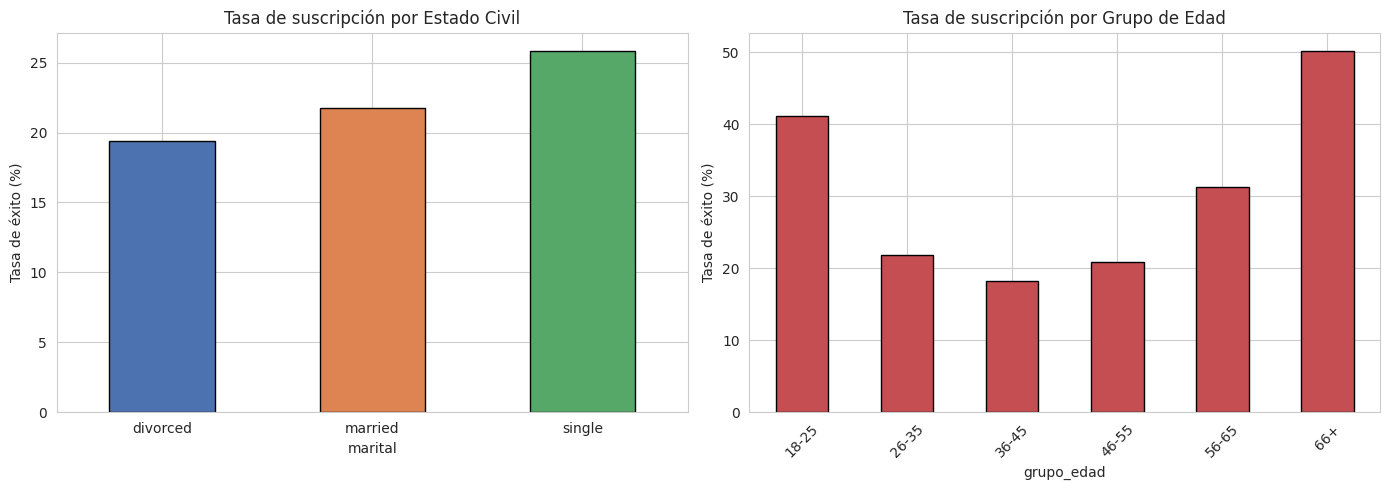

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

tasa_estado_civil.plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black")
ax[0].set_title("Tasa de suscripción por Estado Civil", fontsize=12)
ax[0].set_ylabel("Tasa de éxito (%)")
ax[0].tick_params(axis="x", rotation=0)

tasa_grupo_edad.plot(kind="bar", ax=ax[1], color="#C44E52", edgecolor="black")
ax[1].set_title("Tasa de suscripción por Grupo de Edad", fontsize=12)
ax[1].set_ylabel("Tasa de éxito (%)")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Detección de variables proxy

¿Alguna variable "neutral" correlaciona fuertemente con `marital` o `grupo_edad`? Probamos con `job` (ocupación), que suele repartirse de forma desigual por edad y estado civil.

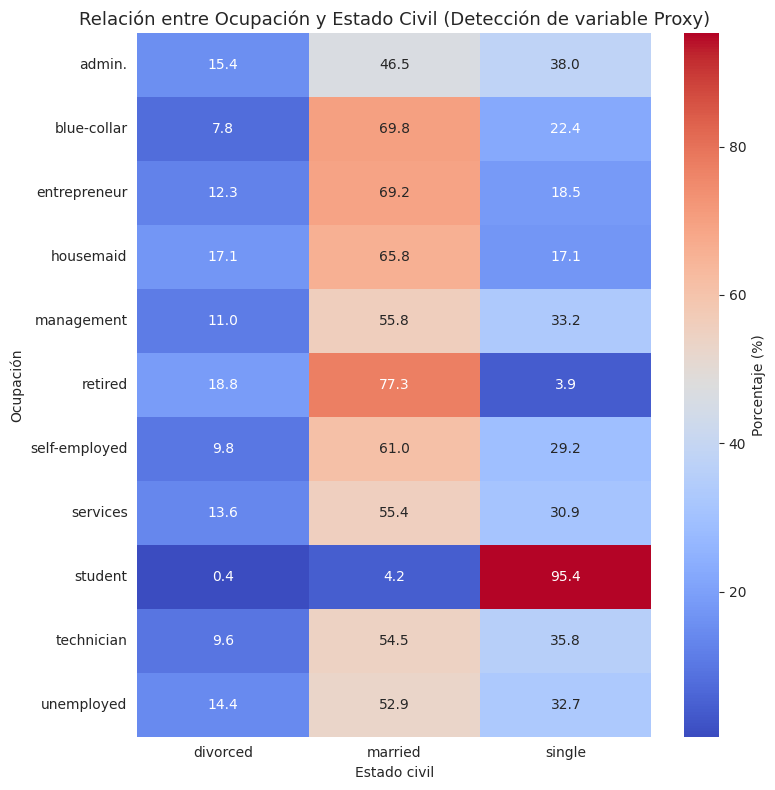

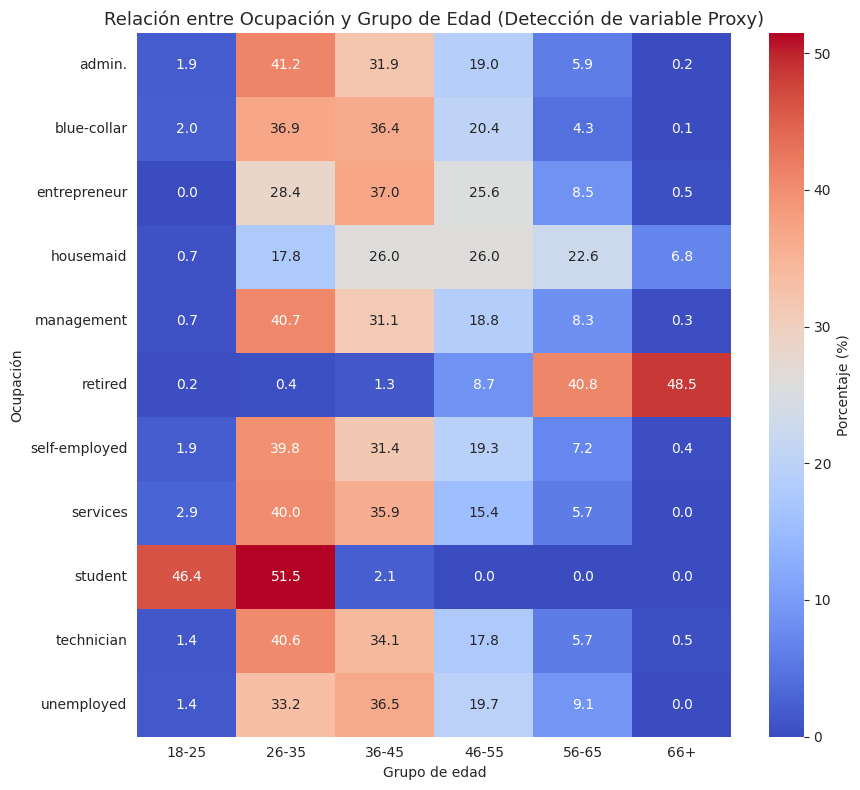

In [ ]:
# Tabla cruzada entre ocupación (job) y estado civil, normalizada por fila
crosstab_job_marital = pd.crosstab(
    df_limpio["job"],
    df_limpio["marital"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 8))
sns.heatmap(
    crosstab_job_marital,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Porcentaje (%)"}
)
plt.title("Relación entre Ocupación y Estado Civil (Detección de variable Proxy)", fontsize=13)
plt.xlabel("Estado civil")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

# Tabla cruzada entre ocupación (job) y grupo de edad
crosstab_job_edad = pd.crosstab(
    df_limpio["job"],
    df_limpio["grupo_edad"],
    normalize="index"
) * 100

plt.figure(figsize=(9, 8))
sns.heatmap(
    crosstab_job_edad,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    cbar_kws={"label": "Porcentaje (%)"}
)
plt.title("Relación entre Ocupación y Grupo de Edad (Detección de variable Proxy)", fontsize=13)
plt.xlabel("Grupo de edad")
plt.ylabel("Ocupación")
plt.tight_layout()
plt.show()

**Pregunta guía:** ¿hay ocupaciones dominadas casi por completo por un solo estado civil o grupo de edad (por ejemplo, `"student"` y `"retired"`)? Si `job` se usa en un modelo, ¿reintroduce el sesgo por edad o estado civil que en teoría se había "controlado"?

## 7. Reflexión escrita (entregable individual)

Responde en máximo una página, con base en los resultados obtenidos arriba:

1. ¿Qué variable(s) sensible(s) identificaste y qué disparidad encontraste (incluye el número exacto de `disparidad_estado_civil` y `disparidad_edad`)?
2. ¿La limpieza aplicada (`dropna()` sobre los `"unknown"`) alteró la proporción de algún grupo de estado civil o de edad? ¿Cómo lo verificaste?
3. ¿Encontraste alguna variable proxy? Argumenta con evidencia de los crosstabs/heatmaps.
4. Propón una mitigación concreta (no genérica) para este dataset específico (por ejemplo, relacionada con cómo se define "éxito" de campaña, o cómo se maneja `job`/`age` en un futuro modelo).